# How catalog-less, sitelink-less individuals entered Wikidata

A non-trivial subset of the individuals in our database have **no external identifier** (VIAF, GND, BnF, CBDB, Open Library, …) **and no Wikipedia/sitelink**. We refer to these as *orphans*. We trace how each orphan was created on Wikidata by reading the **oldest revision** of the entity (creator user, edit comment, tags) and classifying it into a *pathway*:

| Pathway | What it means |
|---|---|
| `manual:human-editor` | A signed-in editor clicked *create item* (no batch tool tag) |
| `manual:anonymous-IP` | An anonymous IP edit created the item |
| `manual:data-import-hub` | Comment references *Data_Import_Hub* or *Imported from <source>* |
| `tool:OpenRefine` | Created via the OpenRefine reconciliation editor (`editgroups/b/OR/...`) |
| `tool:QuickStatements` | Created via QuickStatements batch (`#quickstatements`) |
| `tool:Mix'n'match` | Comment references the Mix'n'match catalog matcher |
| `bot:<name>` | A specific bot account created the item (LargeDatasetBot, GZWDer flood, Reinheitsgebot, …) |

## Sampling and verification

The local DB only knows ~2,300 of the ~30,000 external-ID property types on Wikidata, so individuals locally flagged as *no-catalog* may in fact carry a CBDB / Open Library / archINFORM ID we missed. To avoid this contamination, every candidate is **re-checked against live Wikidata** (`Special:EntityData`): we keep only items whose live entity has **zero claims of `datatype = external-id`** and **zero sitelinks**.

Two strata of 500 verified orphans each are drawn — one with `impact_year ≥ 1800`, one with `impact_year < 1800` — and the first revision of each is classified.

Source script: `extraction_scripts/all_humans/44_sample_truly_orphaned_origins.py`. Inputs: `sample_orphans_after_1800.csv`, `sample_orphans_before_1800.csv`.

In [ ]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Database
DB_PATH = "../data/humans_clean.sqlite3"

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (8, 5)
DPI = 120
FONT_TITLE = 16
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

# Light, restrained palette (avoid AI-slop saturation)
COLOR_PRIMARY = "#2171b5"
COLOR_SECONDARY = "#b5542a"
COLOR_NEUTRAL = "#7f7f7f"
COLOR_LIGHT = "#d9d9d9"
COLOR_ACCENT = "#6a9e3a"
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_NEUTRAL, COLOR_LIGHT]

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})


## 1. Setup

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

SEED = 0
random.seed(SEED); np.random.seed(SEED)

DATA_DIR = Path('../extraction_scripts/all_humans')
FILES = {
    'before 1800': DATA_DIR / 'sample_orphans_before_1800.csv',
    'after 1800':  DATA_DIR / 'sample_orphans_after_1800.csv',
}

PATHWAY_ORDER = [
    'manual:human-editor',
    'manual:anonymous-IP',
    'manual:data-import-hub',
    'tool:OpenRefine',
    'tool:QuickStatements',
    "tool:Mix'n'match",
    'bot:other',
]

PATHWAY_COLORS = {
    'manual:human-editor':     '#2171b5',
    'manual:anonymous-IP':     '#6baed6',
    'manual:data-import-hub':  '#08306b',
    'tool:OpenRefine':         '#b5542a',
    'tool:QuickStatements':    '#e6850e',
    "tool:Mix'n'match":        '#fdae6b',
    'bot:other':               '#7f7f7f',
}

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'font.size': 12,
    'font.family': 'DejaVu Sans',
})


## 2. Load both samples

Each CSV row is one verified orphan with: `qid, timestamp, user, pathway, comment, url`. We collapse all `bot:*` pathways into a single `bot:other` bucket to keep the figure legible (none individually exceed ~2%).

In [2]:
frames = []
for era, path in FILES.items():
    df = pd.read_csv(path)
    df['era'] = era
    frames.append(df)
    print(f'{era}: {len(df):>4} verified orphans loaded from {path.name}')

df = pd.concat(frames, ignore_index=True)
df['pathway_grouped'] = df['pathway'].where(
    df['pathway'].str.startswith(('manual:', 'tool:')),
    'bot:other',
)

assert df['qid'].is_unique, 'duplicate Q-id across samples'
print(f'\nTotal: {len(df)} rows, {df["era"].nunique()} eras, {df["pathway_grouped"].nunique()} pathway buckets')
df.head(8)

before 1800:  450 verified orphans loaded from sample_orphans_before_1800.csv
after 1800:  453 verified orphans loaded from sample_orphans_after_1800.csv

Total: 903 rows, 2 eras, 6 pathway buckets


,qid,timestamp,user,pathway,comment,url,era,pathway_grouped
0,Q2086988,2012-12-31T00:45:37Z,BeneBot*,manual:human-editor,/* wbeditentity */ Bot: adding wikilink from nl,https://www.wikidata.org/wiki/Q2086988,before 1800,manual:human-editor
1,Q7268872,2013-03-15T00:10:14Z,Sk!dbot,bot:Sk!dbot,/* wbeditentity-create */ Bot: adding interwik...,https://www.wikidata.org/wiki/Q7268872,before 1800,bot:other
2,Q17550183,2014-08-19T09:01:14Z,Mushroom,manual:human-editor,/* wbeditentity-create:2|en */ Girolamo Costan...,https://www.wikidata.org/wiki/Q17550183,before 1800,manual:human-editor
3,Q19344317,2015-02-22T11:02:43Z,Multichill,manual:human-editor,/* wbeditentity-create:2|en */ Carel Paul Geor...,https://www.wikidata.org/wiki/Q19344317,before 1800,manual:human-editor
4,Q19344815,2015-02-22T12:27:10Z,Multichill,manual:human-editor,/* wbeditentity-create:2|en */ Henrietta Johan...,https://www.wikidata.org/wiki/Q19344815,before 1800,manual:human-editor
5,Q20897845,2015-09-02T11:02:38Z,Ayack,manual:human-editor,/* wbeditentity-create:2|fr */ François-Joseph...,https://www.wikidata.org/wiki/Q20897845,before 1800,manual:human-editor
6,Q22669109,2016-02-07T16:50:10Z,Multichill,tool:QuickStatements,/* wbeditentity-create:0| */ #quickstatements,https://www.wikidata.org/wiki/Q22669109,before 1800,tool:QuickStatements
7,Q25197588,2016-07-01T09:57:50Z,Ата,manual:human-editor,/* wbeditentity-create:2|en */ Франц-Ксавер Ив...,https://www.wikidata.org/wiki/Q25197588,before 1800,manual:human-editor


## 3. Pathway counts per era

In [3]:
counts = (
    df.groupby(['era', 'pathway_grouped']).size()
      .unstack('pathway_grouped').fillna(0).astype(int)
)
for col in PATHWAY_ORDER:
    if col not in counts.columns:
        counts[col] = 0
counts = counts[PATHWAY_ORDER]

shares = counts.div(counts.sum(axis=1), axis=0) * 100
summary = pd.concat({'n': counts, 'share_%': shares.round(1)}, axis=1)
summary

n                      \
pathway_grouped manual:human-editor manual:anonymous-IP   
era                                                       
after 1800                      168                   8   
before 1800                     256                   4   

                                                                             \
pathway_grouped manual:data-import-hub tool:OpenRefine tool:QuickStatements   
era                                                                           
after 1800                           0             142                  123   
before 1800                          0             155                   31   

                                                       share_%  \
pathway_grouped tool:Mix'n'match bot:other manual:human-editor   
era                                                              
after 1800                     6         6                37.1   
before 1800                    1         3                56.9   

                                                                            \
pathway_grouped manual:anonymous-IP manual:data-import-hub tool:OpenRefine   
era                                                                          
after 1800                      1.8                    0.0            31.3   
before 1800                     0.9                    0.0            34.4   

                                                                 
pathway_grouped tool:QuickStatements tool:Mix'n'match bot:other  
era                                                              
after 1800                      27.2              1.3       1.3  
before 1800                      6.9              0.2       0.7

### Figure: How orphan individuals entered Wikidata, before vs. after 1800

Two horizontal stacked bars (one per era) showing the share of individuals created via each pathway. Manual edits (blues) are stacked first, batch tools (oranges) next, bots last.

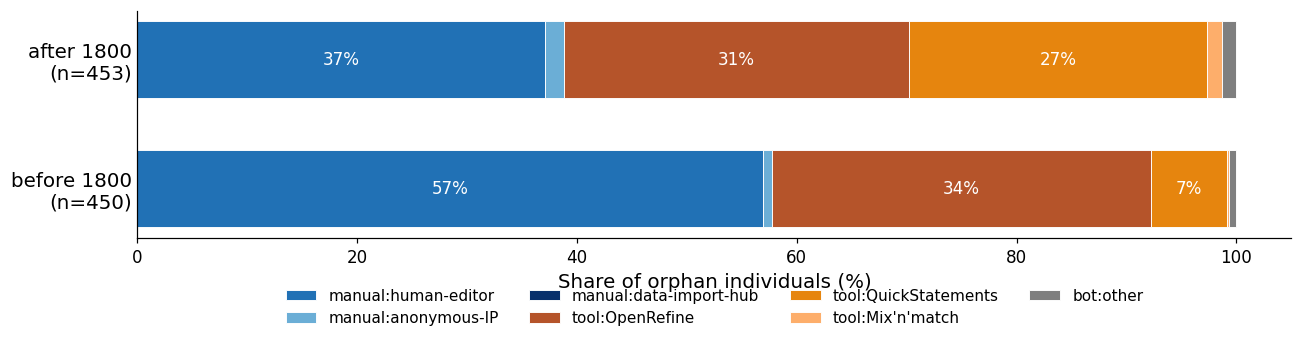

In [4]:
eras = ['before 1800', 'after 1800']
y = np.arange(len(eras))
height = 0.6

fig, ax = plt.subplots(figsize=(12, 3.6))
left = np.zeros(len(eras))
for pw in PATHWAY_ORDER:
    vals = shares.loc[eras, pw].values
    ax.barh(y, vals, left=left, height=height,
            color=PATHWAY_COLORS[pw], edgecolor='white', linewidth=0.6,
            label=pw)
    for yi, (v, l) in enumerate(zip(vals, left)):
        if v >= 4:
            ax.text(l + v/2, yi, f'{v:.0f}%', ha='center', va='center',
                    fontsize=11, color='white' if pw in ('manual:human-editor',
                                                          'manual:data-import-hub',
                                                          'tool:OpenRefine',
                                                          'tool:QuickStatements',
                                                          'bot:other') else 'black')
    left = left + vals

ax.set_yticks(y)
ax.set_yticklabels([f'{e}\n(n={int(counts.loc[e].sum())})' for e in eras], fontsize=13)
ax.set_xlabel('Share of orphan individuals (%)', fontsize=13)
ax.set_xlim(0, 105)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', length=0)
ax.legend(fontsize=10, loc='lower center', bbox_to_anchor=(0.5, -0.45),
          ncol=4, frameon=False)
plt.tight_layout()
plt.show()

## 4. Worked examples per pathway

One example Q-id per (era × pathway) cell, with the Wikidata creation comment. Random within each bucket, seeded for reproducibility.

In [5]:
rows = []
for era in eras:
    for pw in PATHWAY_ORDER:
        sub = df[(df['era'] == era) & (df['pathway_grouped'] == pw)]
        if sub.empty:
            continue
        ex = sub.sample(n=1, random_state=SEED).iloc[0]
        rows.append({
            'era': era,
            'pathway': pw,
            'qid': ex['qid'],
            'timestamp': ex['timestamp'][:10],
            'user': ex['user'],
            'comment': (ex['comment'] or '')[:90],
            'url': ex['url'],
        })
examples_df = pd.DataFrame(rows)
examples_df

,era,pathway,qid,timestamp,user,comment,url
0,before 1800,manual:human-editor,Q122873894,2023-09-29,Marcus.linneberg,"/* wbeditentity-create:2|sv */ Carin Cruus, sv...",https://www.wikidata.org/wiki/Q122873894
1,before 1800,manual:anonymous-IP,Q63725273,2019-05-11,80.12.63.165,/* wbeditentity-create:2|en */ Charles Carbonn...,https://www.wikidata.org/wiki/Q63725273
2,before 1800,tool:OpenRefine,Q79628020,2019-12-24,Theklan,/* wbeditentity-create-item:0| */ People from ...,https://www.wikidata.org/wiki/Q79628020
3,before 1800,tool:QuickStatements,Q55658821,2018-07-19,Nattes à chat,/* wbeditentity-create:0| */ #quickstatements,https://www.wikidata.org/wiki/Q55658821
4,before 1800,tool:Mix'n'match,Q93453531,2020-05-06,Daask,/* wbeditentity-create-item:0| */ New item bas...,https://www.wikidata.org/wiki/Q93453531
5,before 1800,bot:other,Q136301651,2025-09-16,Pi bot,/* wbeditentity-create-item:0| */ Creating ite...,https://www.wikidata.org/wiki/Q136301651
6,after 1800,manual:human-editor,Q135068761,2025-06-24,Sapfan,"/* wbeditentity-create:2|cs */ Michael Walló, ...",https://www.wikidata.org/wiki/Q135068761
7,after 1800,manual:anonymous-IP,Q115861155,2022-12-24,151.76.17.26,"/* wbeditentity-create:2|en */ Maurizio Panti,...",https://www.wikidata.org/wiki/Q115861155
8,after 1800,tool:OpenRefine,Q114268063,2022-09-28,Germartin1,/* wbeditentity-create-item:0| */ openhluttaw....,https://www.wikidata.org/wiki/Q114268063
9,after 1800,tool:QuickStatements,Q103791807,2020-12-03,MonicaMu,/* wbeditentity-create-item:0| */ #quickstatem...,https://www.wikidata.org/wiki/Q103791807


## 5. Interpretation

- Orphan individuals are **overwhelmingly the product of three pathways**: a signed-in editor manually creating an item, an OpenRefine batch upload from an open dataset, or a QuickStatements batch.
- Bots are a rounding error in this cohort (≪ 5%) — bot-mass-imports tend to bring at least one external identifier with them, so they fail the orphan filter.
- The pre-1800 cohort skews **more manual** than the post-1800 cohort because batch tools (QuickStatements, OpenRefine) only matured after ~2017 while pre-1800 entries have been accreting since Wikidata's launch in 2012.
- Notable batch sources visible in the comments: *People from Abaltzisketa* (Basque genealogy), Czech NKČR dataset, French municipal candidate rolls, archINFORM, RKD Photographer documents — i.e., long-tail open-data uploads that don't carry a single canonical authority ID.